# Stage 3 Data Preparation: Teeth Crops for Disease Detection

This notebook prepares the DISEASE_ONLY dataset for Stage 3 using the trained teeth enumeration model. We clean up duplicate ground-truth labels, check how the enumeration model performs on each split, manually review the worst predictions to flag bad images, then export clean teeth crops and apply augmentation.

`dedupe_gt_label_files`, `compare_best_vs_last`, `analyze_full_teeth_predictions`, `get_review_candidates`, and `export_teeth_in_quad_using_enum_model` come from `src/model_utils.py`. `apply_smart_aug` comes from `src/utils.py`.

This notebook has manual review steps built in. Several image filenames are hardcoded after checking them visually, marking which ones to skip during the final export.

In [1]:
import os
import sys
import warnings
warnings.filterwarnings('ignore')
# add the project root to the path so the src package can be imported
sys.path.append(os.path.abspath('..'))

import yaml
import numpy as np
from ultralytics import YOLO
from src.create_dataframe import build_and_export_dataframes
from src.utils import apply_smart_aug
from src.model_utils import export_teeth_in_quad_using_enum_model,analyze_full_teeth_predictions,compare_best_vs_last,get_review_candidates,dedupe_gt_label_files


## Load configs

We'll load configs for stage 2, the continued stage 2 (DISEASE_ONLY) variant, and stage 3, plus their data yamls and the trained models config that tracks which checkpoints we're comparing.

In [2]:
with open('../configs/stage2.yaml','r') as f:

    stage2_config = yaml.safe_load(f)


with open('../configs/stage2_continued.yaml','r') as f:

    stage2_cont_config = yaml.safe_load(f)


with open('../configs/stage3.yaml','r') as f:

    stage3_config = yaml.safe_load(f)


# comes from stage2_config, so that has to load first
with open(stage2_config['model_args']['data'],'r') as f:

    enum_data_yaml = yaml.safe_load(f)


# comes from stage2_cont_config, so that has to load first
with open(stage2_cont_config['model_args']['data'],'r') as f:

    enum_cont_data_yaml = yaml.safe_load(f)


with open('../configs/trained_models.yaml','r') as f:

    trained_models_config = yaml.safe_load(f)

## Clean up ground-truth labels

Before evaluating the model, let's remove any duplicate rows in the ground-truth label files for the DISEASE_ONLY train, valid, and test splits. `dry_run=False` means this actually rewrites the files, not just previews the change.

In [83]:
dedupe_gt_label_files(enum_cont_data_yaml['DISEASE_ONLY']['train'].replace('images','labels'),dry_run=False)

100%|██████████| 1439/1439 [00:00<00:00, 6290.54it/s]

Files with duplicates: 0 out of 1439


""


In [84]:
dedupe_gt_label_files(enum_cont_data_yaml['DISEASE_ONLY']['val'].replace('images','labels'),dry_run=False)

100%|██████████| 181/181 [00:00<00:00, 6642.25it/s]

Files with duplicates: 0 out of 181


""


In [85]:
dedupe_gt_label_files(enum_cont_data_yaml['DISEASE_ONLY']['test'].replace('images','labels'),dry_run=False)

100%|██████████| 175/175 [00:00<00:00, 6595.05it/s]

Files with duplicates: 0 out of 175


""


## Compare checkpoints

Let's check how the best and last checkpoints of the enumeration model perform, first on the stage 2 test set as a baseline, then on all three DISEASE_ONLY splits for stage 3.

In [86]:
# baseline check on the stage 2 test set before moving to stage 3 data
s2_test_results = compare_best_vs_last(enum_data_yaml,trained_models_config,
                                'enum',
                                'test',
                                main_result_path='../Runs/Stage 2/Enumeration Model Crop Analysis')


Running best and last weights on the test set (stage: enum)
enumeration_detection_model - best


100%|██████████| 248/248 [00:08<00:00, 28.06it/s]



Top 10 problematic images (most warnings):
  duplicates: 3, low_confidence: 1, missing: 132, leaks: 0, background: 0, successful: 8, avg_conf: 0.8237
enumeration_detection_model - last


100%|██████████| 248/248 [00:08<00:00, 29.85it/s]


Top 10 problematic images (most warnings):
  duplicates: 3, low_confidence: 0, missing: 132, leaks: 0, background: 0, successful: 6, avg_conf: 0.8833

Test set summary
enumeration_detection_model_best: total_errors=4, avg_confidence=0.8237
enumeration_detection_model_last: total_errors=3, avg_confidence=0.8833

Lowest total errors on test set: enumeration_detection_model_last with 3 errors


In [87]:
s3_train_results = compare_best_vs_last(enum_cont_data_yaml['DISEASE_ONLY'],trained_models_config,
                                'enum',
                                'train',
                                main_result_path='../Runs/Stage 3/Enumeration Model Crop Analysis')


Running best and last weights on the test set (stage: enum)
enumeration_detection_model - best


100%|██████████| 1439/1439 [00:52<00:00, 27.54it/s]



Top 10 problematic images (most warnings):
  duplicates: 240, low_confidence: 126, missing: 834, leaks: 166, background: 1, successful: 7613, avg_conf: 0.9205
enumeration_detection_model - last


100%|██████████| 1439/1439 [00:50<00:00, 28.25it/s]



Top 10 problematic images (most warnings):
  duplicates: 176, low_confidence: 103, missing: 831, leaks: 161, background: 1, successful: 7617, avg_conf: 0.9372

Test set summary
enumeration_detection_model_best: total_errors=533, avg_confidence=0.9205
enumeration_detection_model_last: total_errors=441, avg_confidence=0.9372

Lowest total errors on test set: enumeration_detection_model_last with 441 errors


In [88]:
s3_valid_results = compare_best_vs_last(enum_cont_data_yaml['DISEASE_ONLY'],trained_models_config,
                                'enum',
                                'valid',
                                main_result_path='../Runs/Stage 3/Enumeration Model Crop Analysis')


Running best and last weights on the test set (stage: enum)
enumeration_detection_model - best


100%|██████████| 181/181 [00:06<00:00, 26.43it/s]



Top 10 problematic images (most warnings):
  duplicates: 23, low_confidence: 16, missing: 104, leaks: 17, background: 0, successful: 963, avg_conf: 0.9171
enumeration_detection_model - last


100%|██████████| 181/181 [00:06<00:00, 28.37it/s]


Top 10 problematic images (most warnings):
  duplicates: 27, low_confidence: 16, missing: 103, leaks: 15, background: 0, successful: 965, avg_conf: 0.9309

Test set summary
enumeration_detection_model_best: total_errors=56, avg_confidence=0.9171
enumeration_detection_model_last: total_errors=58, avg_confidence=0.9309

Lowest total errors on test set: enumeration_detection_model_best with 56 errors


In [89]:
s3_test_results = compare_best_vs_last(enum_cont_data_yaml['DISEASE_ONLY'],trained_models_config,
                                'enum',
                                'test',
                                main_result_path='../Runs/Stage 3/Enumeration Model Crop Analysis')


Running best and last weights on the test set (stage: enum)
enumeration_detection_model - best


100%|██████████| 175/175 [00:06<00:00, 26.06it/s]



Top 10 problematic images (most warnings):
  duplicates: 23, low_confidence: 12, missing: 93, leaks: 25, background: 0, successful: 953, avg_conf: 0.9252
enumeration_detection_model - last


100%|██████████| 175/175 [00:06<00:00, 26.94it/s]


Top 10 problematic images (most warnings):
  duplicates: 18, low_confidence: 11, missing: 87, leaks: 22, background: 0, successful: 960, avg_conf: 0.9410

Test set summary
enumeration_detection_model_best: total_errors=60, avg_confidence=0.9252
enumeration_detection_model_last: total_errors=51, avg_confidence=0.9410

Lowest total errors on test set: enumeration_detection_model_last with 51 errors


## Analyze predictions

For each split we'll pull out the log dataframe, run `analyze_full_teeth_predictions` to summarize it, and get review candidates worth a manual look. The `event` column tells us what happened per box. `allowed_events` lists the outcomes we consider normal; anything outside that list is what we review by hand next.

Total images processed: 248
Total events logged: 2155



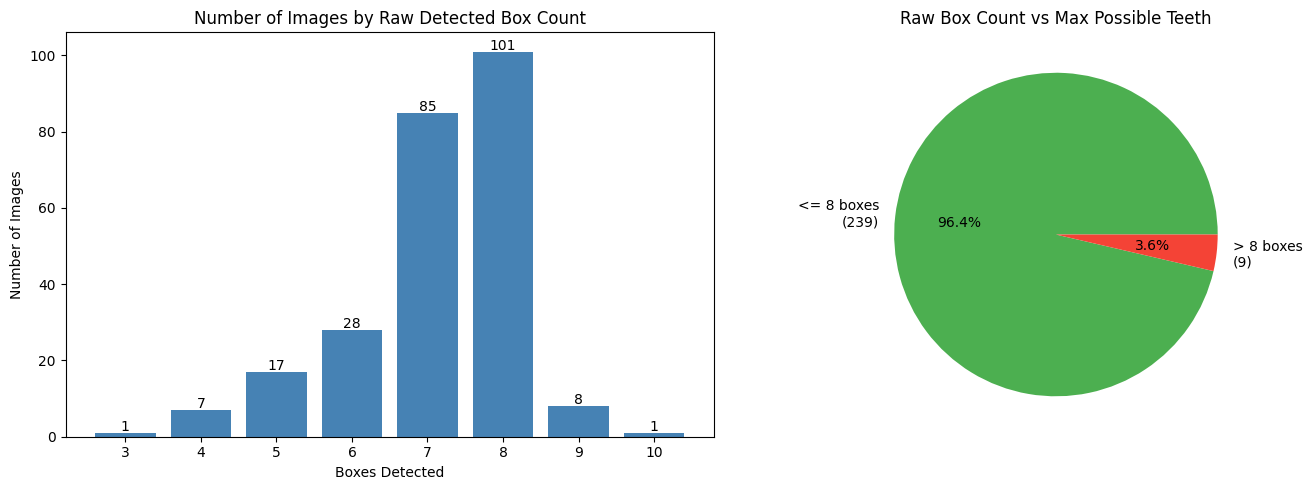

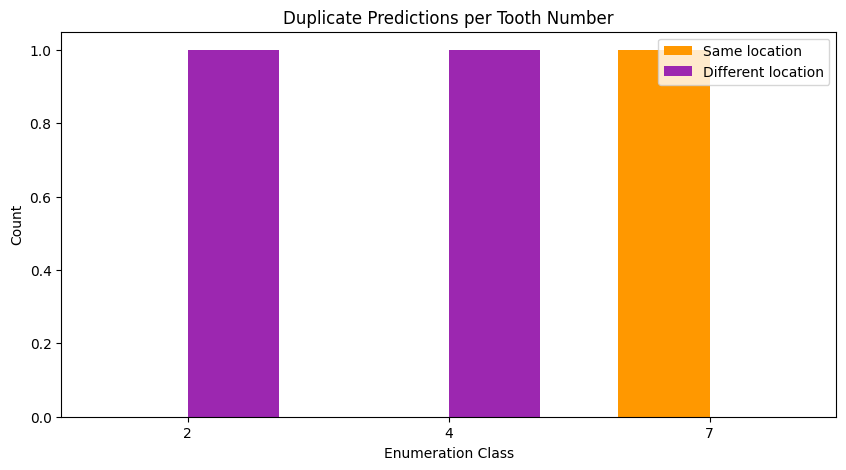

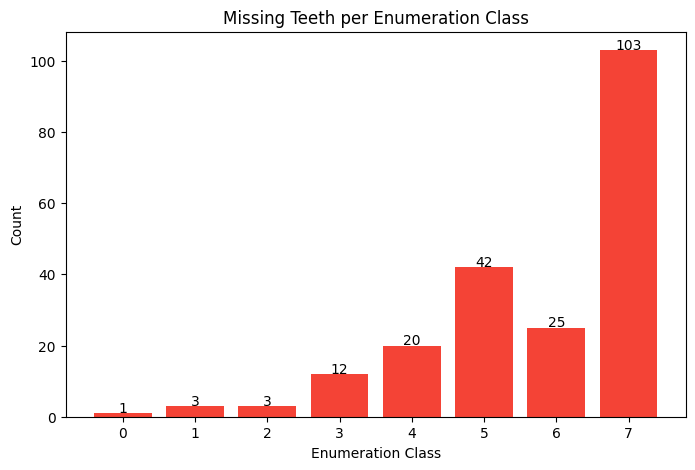

Note: a missing tooth number isn't necessarily an error, not every quadrant has all 8 teeth present.

Predictions skipped because the tooth already had a disease label: 1727
No possible cross-quadrant leaks flagged.
No possible background predictions flagged.
No low confidence predictions found.

Average HIGH confidence (>= 0.6): 0.931
Average LOW confidence  (< 0.6): 0.437
Confidence Gap: 0.493  (std=0.110, n_low=60 -> large, model is inconsistent)


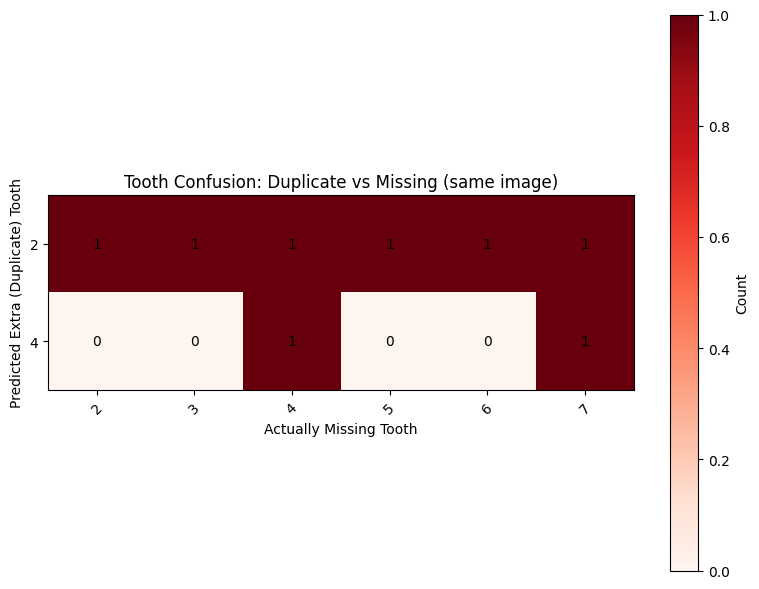


Top 10 problematic images (most warnings):
File_Name
train_386_UpperRight.png    2
train_538_LowerRight.png    2
train_565_UpperRight.png    2
train_109_LowerLeft.png     1
train_109_LowerRight.png    1
train_109_UpperLeft.png     1
train_109_UpperRight.png    1
train_119_LowerLeft.png     1
train_119_LowerRight.png    1
train_119_UpperLeft.png     1
Name: count, dtype: int64

Exported worst images log to: ../Runs/Stage 2/Enumeration Model Crop Analysis\test
File Name: train_332_LowerRight.png
Reason: tooth 4 conflicts with anchors (expected class between 5 and 6)
File Name: train_342_UpperRight.png
Reason: tooth 7 box is 1.7x the median width, may span two teeth
File Name: train_384_UpperRight.png
Reason: tooth 7 box is 1.6x the median width, may span two teeth


In [90]:
# always pull the 'last' checkpoint results here, even though we just compared both above
s2_test_log_df = s2_test_results['test_set_results']['enumeration_detection_model_last']['log_df']
analyze_full_teeth_predictions(s2_test_log_df,export_dir='../Runs/Stage 2/Enumeration Model Crop Analysis',split_name='test')
get_review_candidates(s2_test_log_df)

Total images processed: 1439
Total events logged: 14040



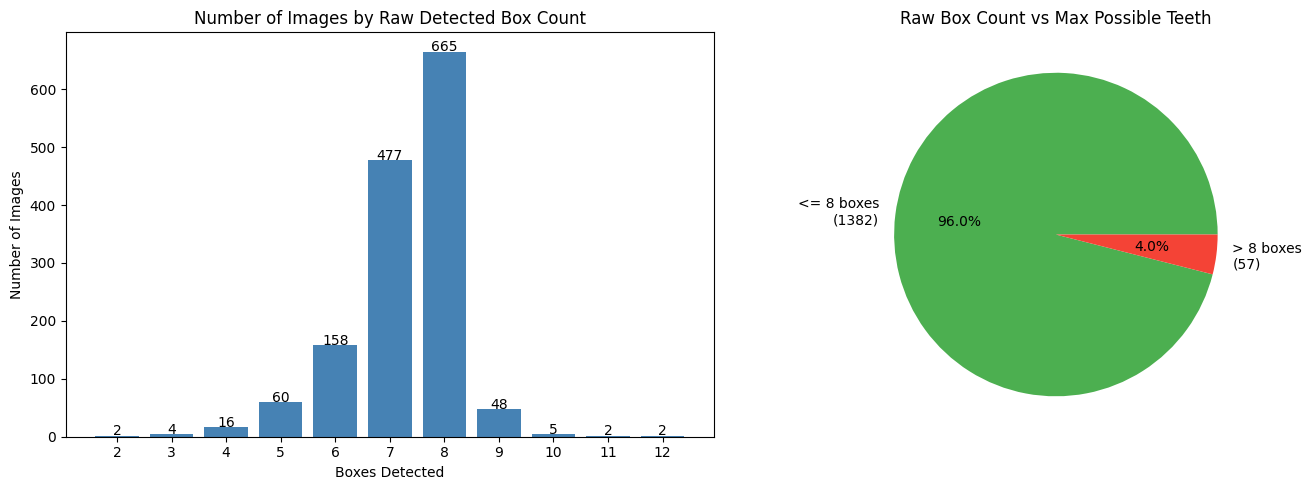

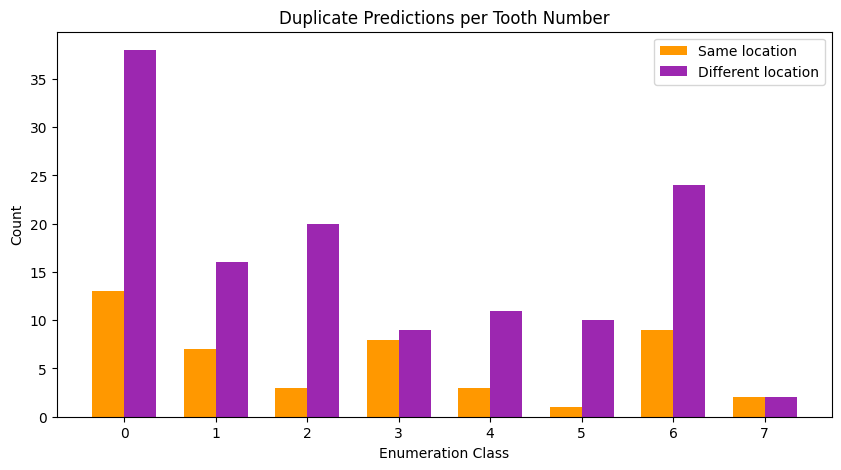

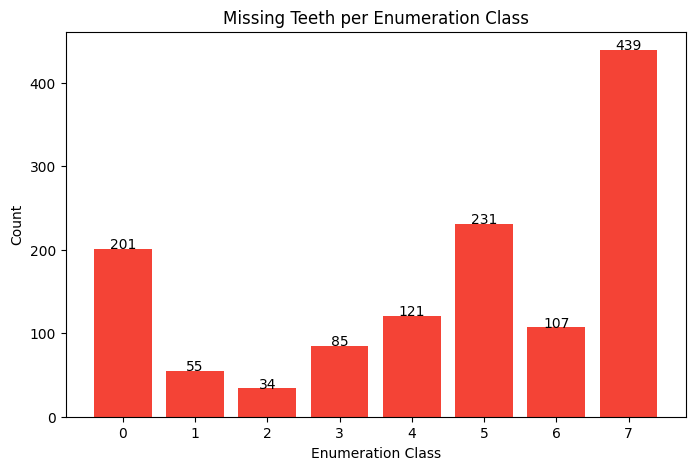

Note: a missing tooth number isn't necessarily an error, not every quadrant has all 8 teeth present.

Predictions skipped because the tooth already had a disease label: 2466


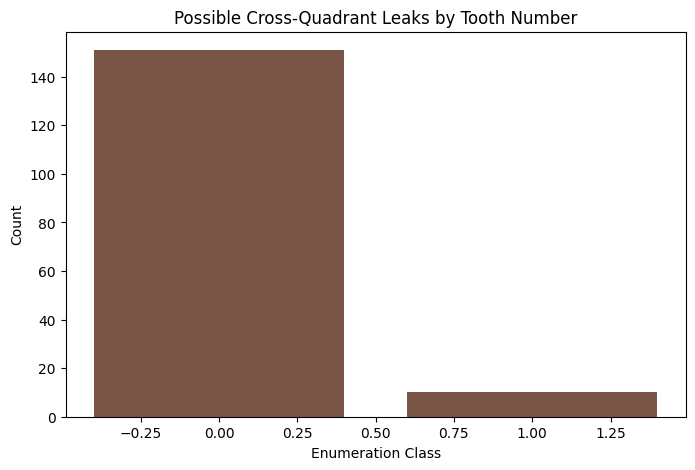

Total possible cross-quadrant leaks flagged: 161 (heuristic, worth a manual look)


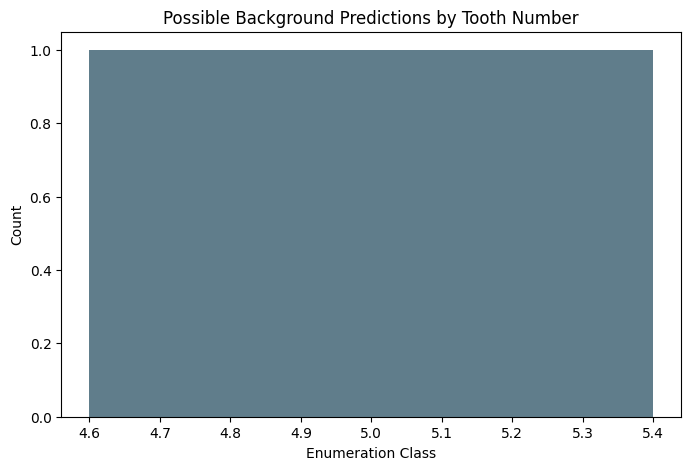

Total possible background predictions flagged: 1 (heuristic, worth a manual look)


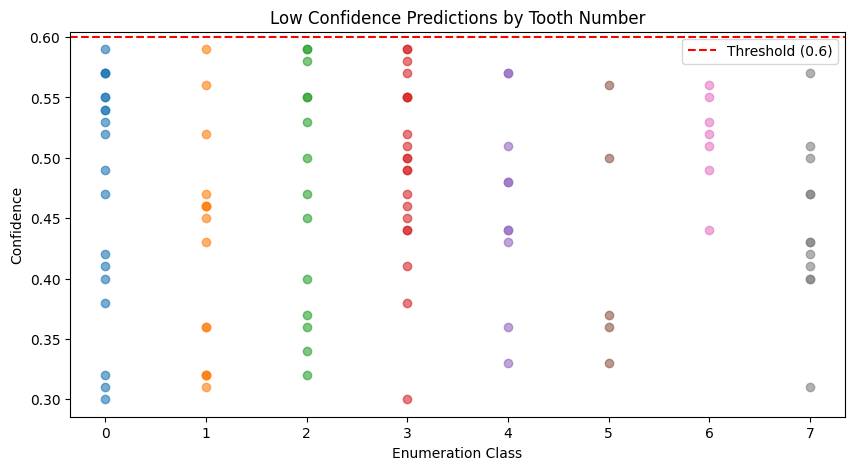


Total low confidence warnings: 103
            count      mean   min
enum_class                       
0              19  0.475263  0.30
1              15  0.426000  0.31
2              14  0.471429  0.32
3              21  0.492381  0.30
4              10  0.461000  0.33
5               5  0.424000  0.33
6               7  0.514286  0.44
7              12  0.443333  0.31

Average HIGH confidence (>= 0.6): 0.943
Average LOW confidence  (< 0.6): 0.457
Confidence Gap: 0.486  (std=0.105, n_low=402 -> large, model is inconsistent)


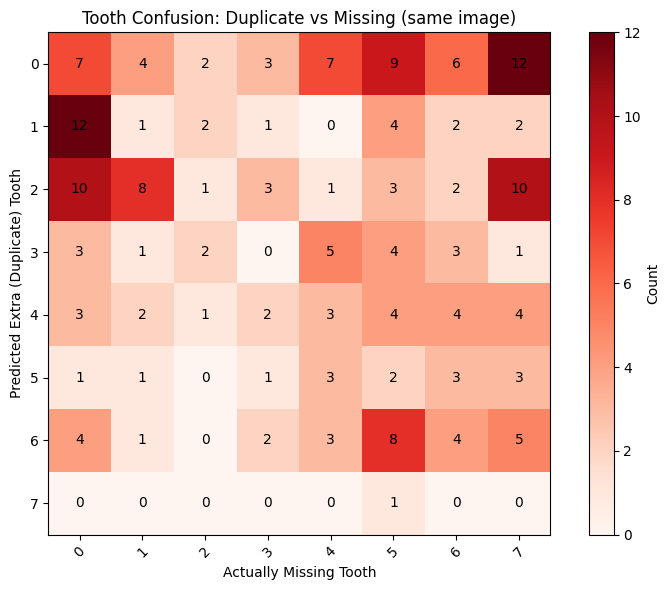


Top 10 problematic images (most warnings):
File_Name
train_370_LowerRight.png    6
train_664_LowerRight.png    6
train_251_LowerLeft.png     5
train_616_LowerLeft.png     5
train_143_UpperRight.png    4
train_172_LowerRight.png    4
train_230_LowerRight.png    4
train_254_UpperLeft.png     4
train_420_LowerLeft.png     4
train_481_LowerRight.png    4
Name: count, dtype: int64

Exported worst images log to: ../Runs/Stage 3/Enumeration Model Crop Analysis\train


In [91]:
s3_train_log_df = s3_train_results['test_set_results']['enumeration_detection_model_last']['log_df']
s3_train_worst_df = s3_train_results['test_set_results']['enumeration_detection_model_last']['worst_images_df']

analyze_full_teeth_predictions(s3_train_log_df,export_dir='../Runs/Stage 3/Enumeration Model Crop Analysis',split_name='train')
s3_train_review = get_review_candidates(s3_train_log_df,True)

Total images processed: 181
Total events logged: 1758



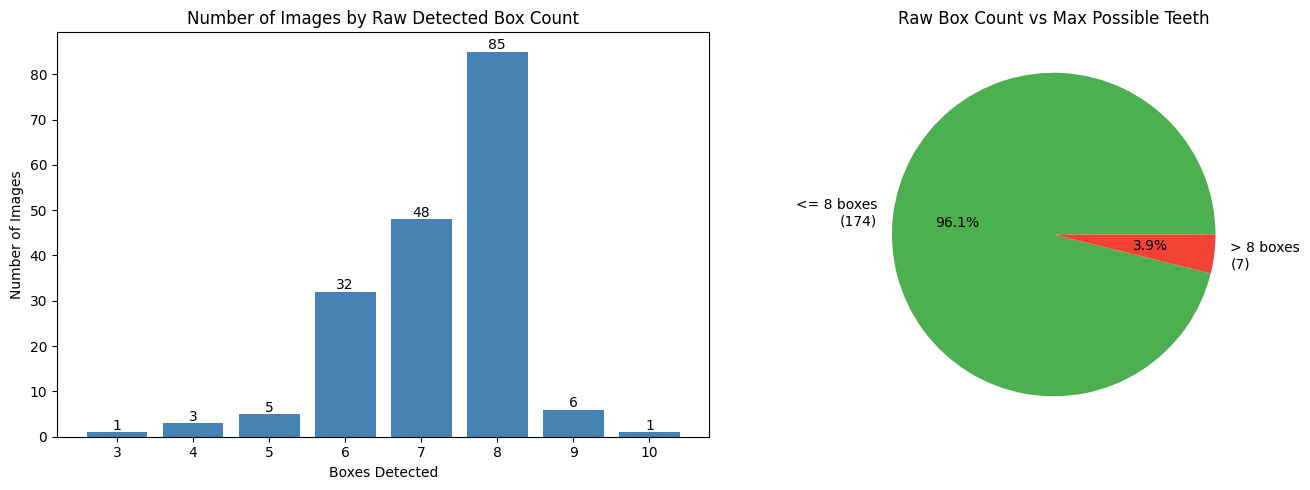

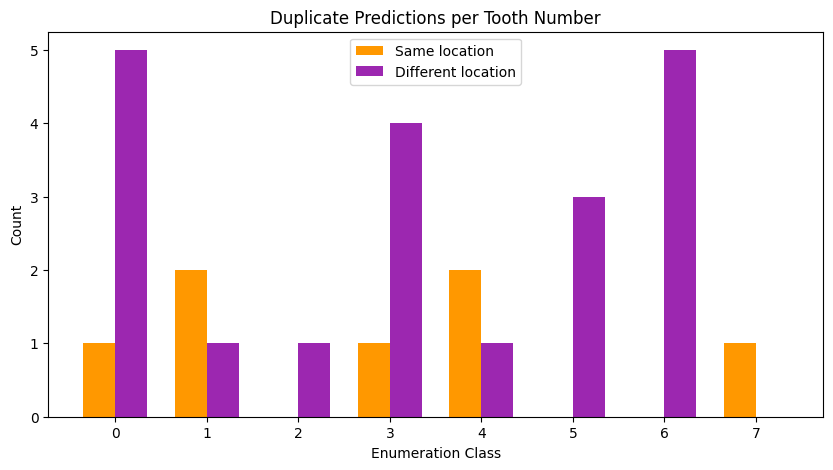

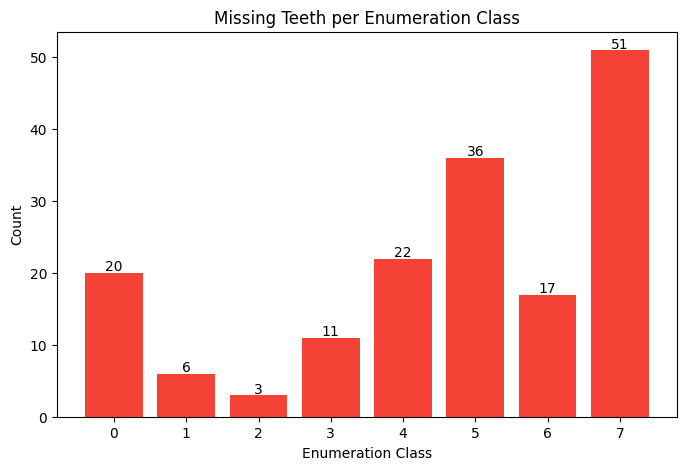

Note: a missing tooth number isn't necessarily an error, not every quadrant has all 8 teeth present.

Predictions skipped because the tooth already had a disease label: 292


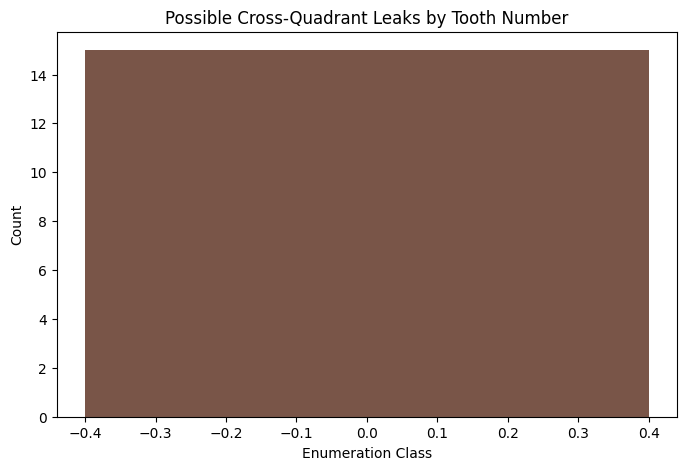

Total possible cross-quadrant leaks flagged: 15 (heuristic, worth a manual look)
No possible background predictions flagged.


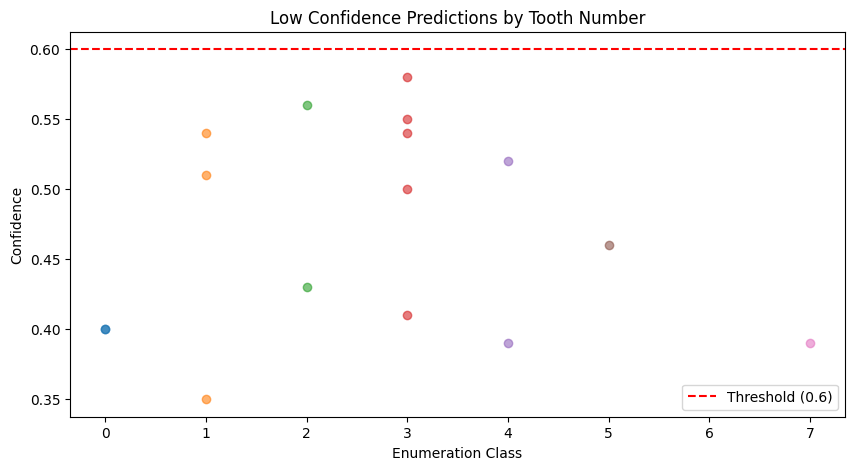


Total low confidence warnings: 16
            count      mean   min
enum_class                       
0               2  0.400000  0.40
1               3  0.466667  0.35
2               2  0.495000  0.43
3               5  0.516000  0.41
4               2  0.455000  0.39
5               1  0.460000  0.46
7               1  0.390000  0.39

Average HIGH confidence (>= 0.6): 0.938
Average LOW confidence  (< 0.6): 0.455
Confidence Gap: 0.483  (std=0.113, n_low=59 -> large, model is inconsistent)


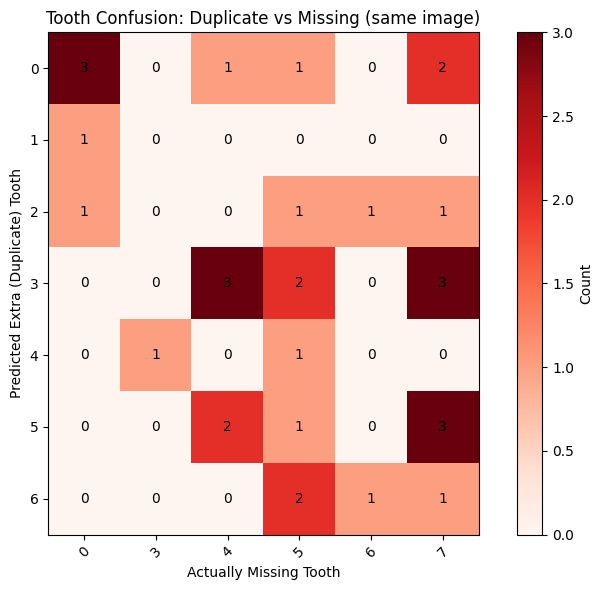


Top 10 problematic images (most warnings):
File_Name
train_40_UpperLeft.png      5
train_522_UpperRight.png    5
train_30_LowerRight.png     4
train_474_LowerLeft.png     3
train_514_UpperLeft.png     3
train_691_LowerLeft.png     3
train_101_LowerLeft.png     2
train_11_LowerRight.png     2
train_148_LowerLeft.png     2
train_187_LowerRight.png    2
Name: count, dtype: int64

Exported worst images log to: ../Runs/Stage 3/Enumeration Model Crop Analysis\valid
File Name: train_101_LowerRight.png
Reason: tooth 5 box is 2.4x the median width, may span two teeth | tooth 6 box is 3.0x the median width, may span two teeth
File Name: train_148_LowerLeft.png
Reason: tooth 6 box is 1.7x the median width, may span two teeth
File Name: train_148_LowerRight.png
Reason: tooth 5 box is 2.1x the median width, may span two teeth
File Name: train_148_UpperLeft.png
Reason: tooth 6 box is 1.6x the median width, may span two teeth
File Name: train_156_LowerRight.png
Reason: tooth 6 box is 1.9x the median

In [92]:
s3_valid_log_df = s3_valid_results['test_set_results']['enumeration_detection_model_last']['log_df']
s3_valid_worst_df = s3_valid_results['test_set_results']['enumeration_detection_model_last']['worst_images_df']
analyze_full_teeth_predictions(s3_valid_log_df,export_dir='../Runs/Stage 3/Enumeration Model Crop Analysis',split_name='valid')
get_review_candidates(s3_valid_log_df)

Total images processed: 175
Total events logged: 1734



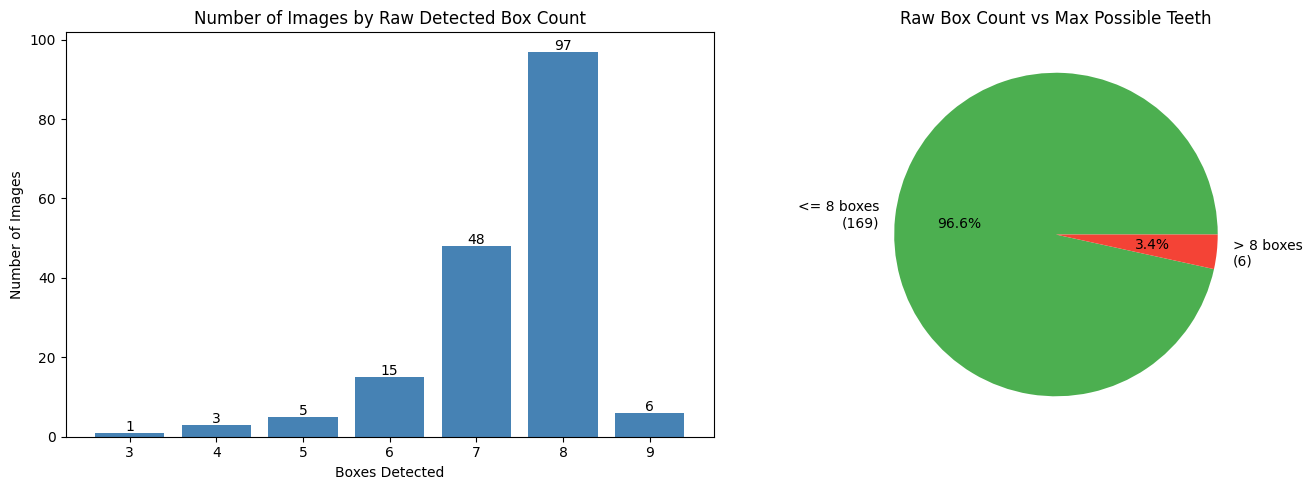

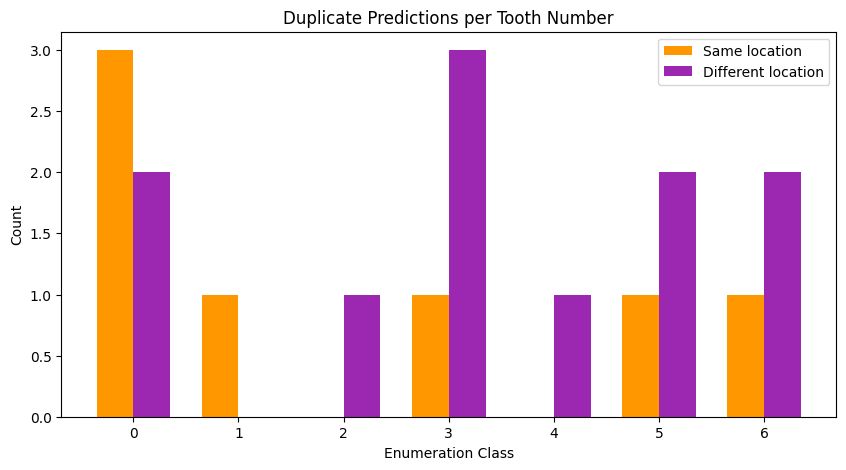

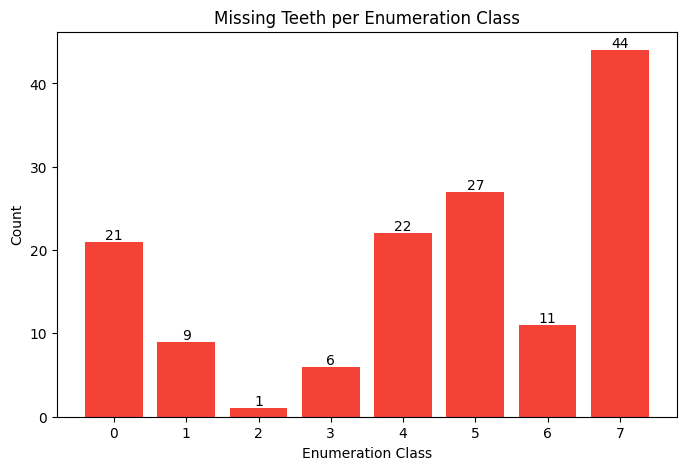

Note: a missing tooth number isn't necessarily an error, not every quadrant has all 8 teeth present.

Predictions skipped because the tooth already had a disease label: 291


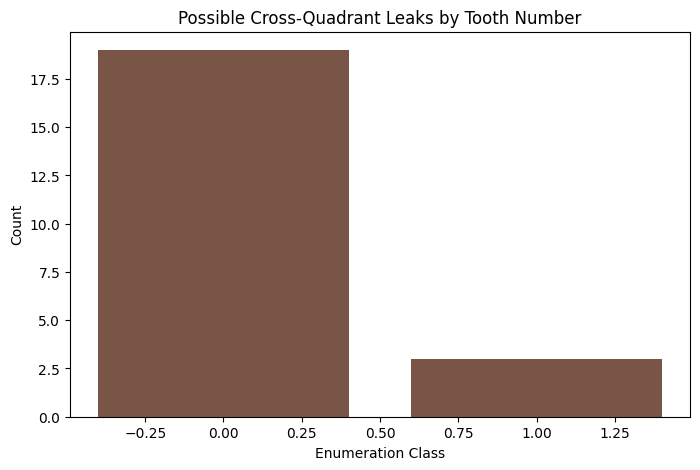

Total possible cross-quadrant leaks flagged: 22 (heuristic, worth a manual look)
No possible background predictions flagged.


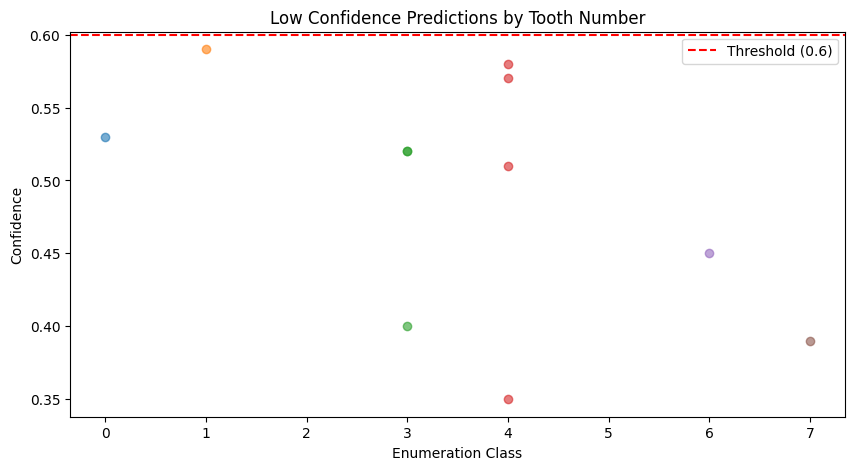


Total low confidence warnings: 11
            count    mean   min
enum_class                     
0               1  0.5300  0.53
1               1  0.5900  0.59
3               3  0.4800  0.40
4               4  0.5025  0.35
6               1  0.4500  0.45
7               1  0.3900  0.39

Average HIGH confidence (>= 0.6): 0.945
Average LOW confidence  (< 0.6): 0.462
Confidence Gap: 0.483  (std=0.098, n_low=43 -> large, model is inconsistent)


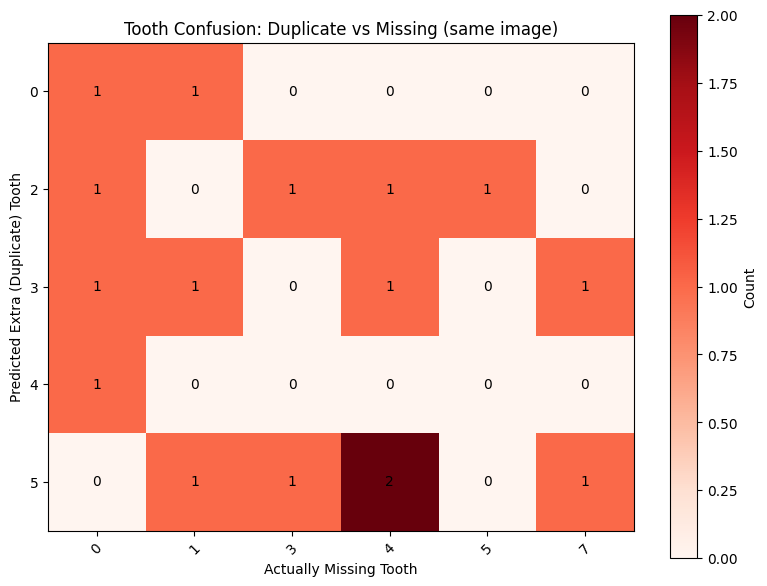


Top 10 problematic images (most warnings):
File_Name
train_66_LowerLeft.png      5
train_132_LowerRight.png    3
train_164_LowerLeft.png     3
train_212_UpperRight.png    3
train_308_UpperRight.png    3
train_621_UpperRight.png    3
train_63_LowerRight.png     3
train_131_LowerLeft.png     2
train_131_LowerRight.png    2
train_132_LowerLeft.png     2
Name: count, dtype: int64

Exported worst images log to: ../Runs/Stage 3/Enumeration Model Crop Analysis\test
File Name: train_110_LowerRight.png
Reason: tooth 6 box is 1.9x the median width, may span two teeth | tooth 5 box is 1.9x the median width, may span two teeth
File Name: train_131_LowerLeft.png
Reason: tooth 6 box is 2.1x the median width, may span two teeth | tooth 5 box is 1.7x the median width, may span two teeth
File Name: train_132_UpperLeft.png
Reason: tooth 6 box is 1.6x the median width, may span two teeth
File Name: train_132_UpperRight.png
Reason: tooth 6 box is 1.6x the median width, may span two teeth
File Name: train

In [93]:
s3_test_log_df = s3_test_results['test_set_results']['enumeration_detection_model_last']['log_df']
s3_test_worst_df = s3_test_results['test_set_results']['enumeration_detection_model_last']['worst_images_df']
analyze_full_teeth_predictions(s3_test_log_df,export_dir='../Runs/Stage 3/Enumeration Model Crop Analysis',split_name='test')
get_review_candidates(s3_test_log_df)

In [ ]:
print(s3_train_log_df['event'].unique())
allowed_events = ['boxes_detected', 'successful_detection','skipped_already_labeled','low_confidence']

<ArrowStringArray>
[       'skipped_already_labeled',           'successful_detection',
            'possible_merged_box',                 'boxes_detected',
            'needs_manual_review',                  'missing_teeth',
            'cross_class_overlap',        'duplicate_same_location',
                 'low_confidence',   'possible_cross_quadrant_leak',
        'duplicate_diff_location',          'ordering_inconsistent',
 'possible_background_prediction']
Length: 13, dtype: str

## Load the enumeration model

We'll use the last checkpoint of the enumeration model going forward, to actually export the teeth crops.

In [ ]:
# load the checkpoint saved at the end of training, this is the model we'll actually use for inference
enum_model_detection = YOLO(trained_models_config['enumeration_detection_model']['last'])

## Manual review of flagged images

Here we go through the worst-scoring and flagged images split by split, running `export_teeth_in_quad_using_enum_model` in debug mode with `export_images=False` and `export_labels=False`, so nothing gets written yet, just previewed. Filenames that turn out bad after a quick look get added to a skip list below; ones that look fine get left alone.

 33%|███▎      | 1/3 [00:00<00:00,  2.38it/s]

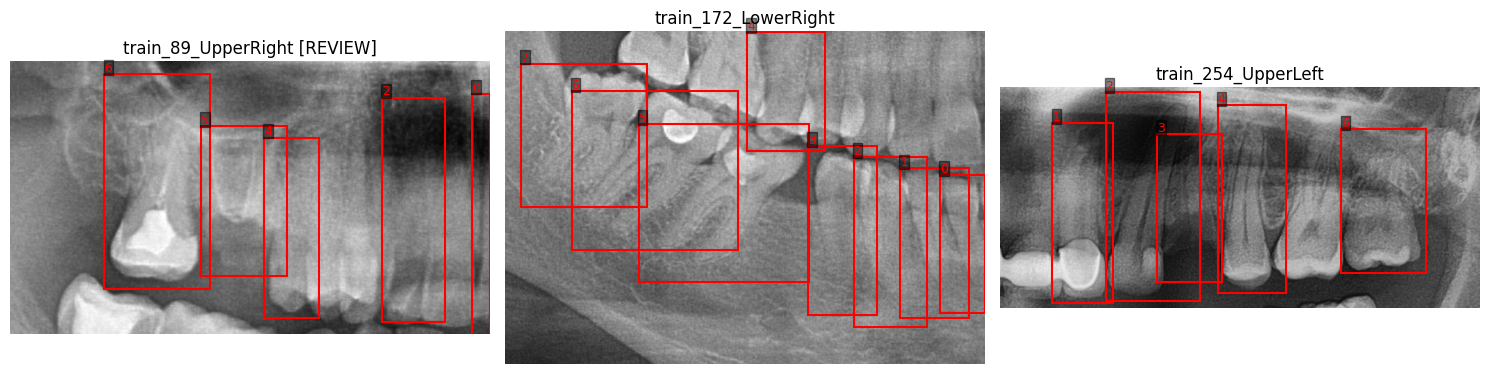

 67%|██████▋   | 2/3 [00:00<00:00,  2.50it/s]


In [ ]:
fname = np.random.choice(s3_train_worst_df['File_Name'].unique()) # If you need to show random images just put fname variable in the List inside at specific_iamge_name parameter

# These 3 images only need to delete after fast review
worst_train_files = ['train_89_UpperRight.png', 'train_172_LowerRight.png', 'train_254_UpperLeft.png']
export_teeth_in_quad_using_enum_model(enum_model_detection,enum_cont_data_yaml['DISEASE_ONLY']['train'],
                                      enum_cont_data_yaml['DISEASE_ONLY']['train'].replace('images','labels'),
                                      debugging=True,debug_limit=len(worst_train_files),
                                      specific_image_name=worst_train_files,
                                      background_area_ratio_high=5,leak_area_ratio=0.3,
                                      export_images=False,
                                      export_labels=False)

  0%|          | 0/2 [00:00<?, ?it/s]

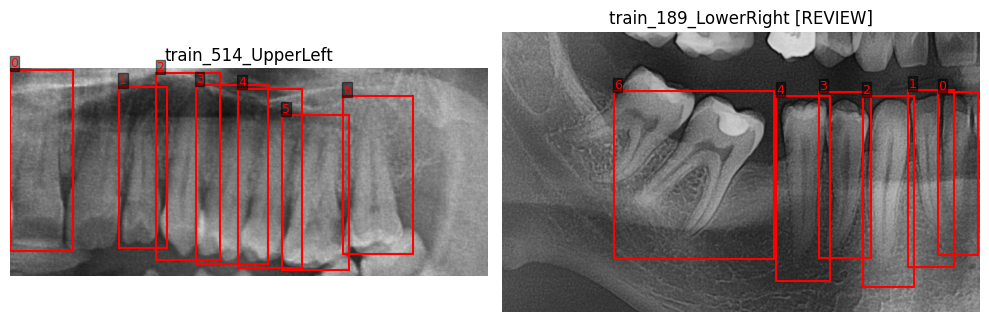

 50%|█████     | 1/2 [00:00<00:00,  3.09it/s]


In [ ]:
fname = np.random.choice(s3_valid_worst_df['File_Name'].unique())

#  These 2 images only need to delete after fast review
worst_valid_files = ['train_514_UpperLeft.png', 'train_189_LowerRight.png']
export_teeth_in_quad_using_enum_model(enum_model_detection,enum_cont_data_yaml['DISEASE_ONLY']['val'],
                                      enum_cont_data_yaml['DISEASE_ONLY']['val'].replace('images','labels'),
                                      debugging=True,debug_limit=len(worst_valid_files),
                                      specific_image_name=worst_valid_files,
                                      background_area_ratio_high=5,leak_area_ratio=0.3,
                                      export_images=False,
                                      export_labels=False)

  0%|          | 0/1 [00:00<?, ?it/s]

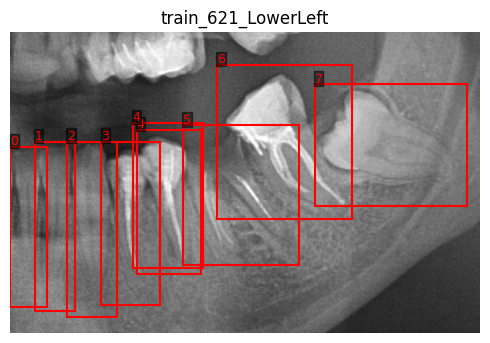

  0%|          | 0/1 [00:00<?, ?it/s]


In [ ]:
fname = np.random.choice(s3_test_worst_df['File_Name'].unique())

worst_test_files = ['train_621_LowerLeft.png'] # => This one only need to delete after fast review
export_teeth_in_quad_using_enum_model(enum_model_detection,enum_cont_data_yaml['DISEASE_ONLY']['test'],
                                      enum_cont_data_yaml['DISEASE_ONLY']['test'].replace('images','labels'),
                                      debugging=True,debug_limit=len(worst_test_files),
                                      specific_image_name=worst_test_files,
                                      background_area_ratio_high=5,leak_area_ratio=0.3,
                                      export_images=False,
                                      export_labels=False)

In [ ]:
s3_train_log_df[s3_train_log_df['event'] == 'possible_background_prediction']

,File_Name,event,enum_class,confidence,n_boxes,crop_area
6338,train_379_LowerRight.png,possible_background_prediction,5,0.98,7,386220.0


  0%|          | 0/1 [00:00<?, ?it/s]

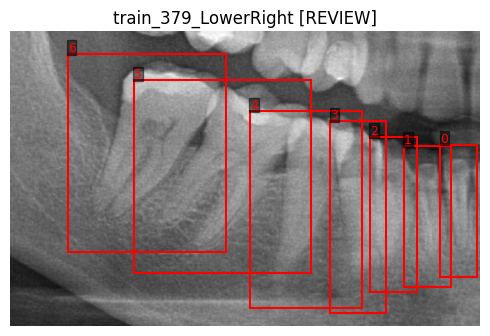

  0%|          | 0/1 [00:00<?, ?it/s]


In [ ]:
# No need to delete them
export_teeth_in_quad_using_enum_model(enum_model_detection,enum_cont_data_yaml['DISEASE_ONLY']['train'],
                                      enum_cont_data_yaml['DISEASE_ONLY']['train'].replace('images','labels'),
                                      debugging=True,debug_limit=1,
                                      specific_image_name=['train_379_LowerRight.png'],background_area_ratio_high=5,leak_area_ratio=0.3,
                                      export_images=False,
                                      export_labels=False)

  0%|          | 0/12 [00:00<?, ?it/s]

 75%|███████▌  | 9/12 [00:00<00:00, 22.22it/s]

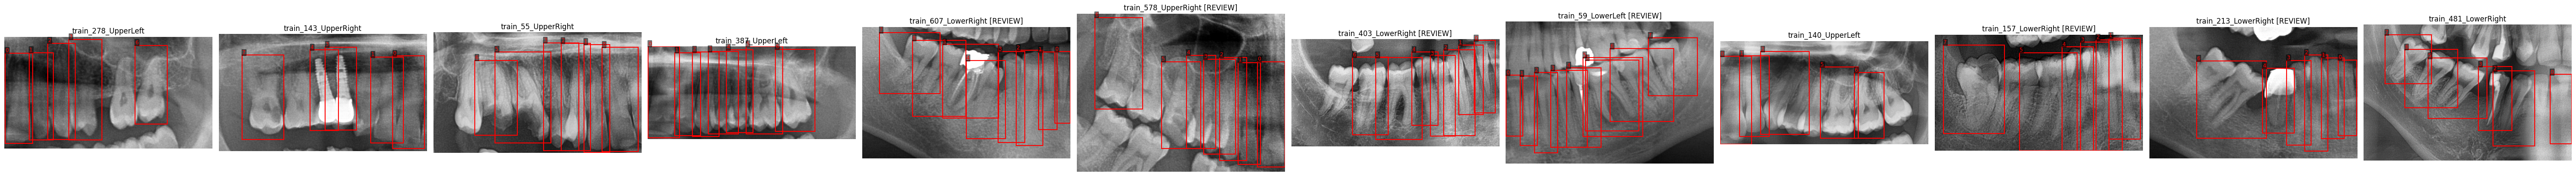

 92%|█████████▏| 11/12 [00:01<00:00,  6.52it/s]


In [ ]:
fname = np.random.choice(s3_train_log_df[~s3_train_log_df['event'].isin(allowed_events)][s3_train_log_df['n_boxes'] < 9]['File_Name'].unique())

# These images need to delete after fast review
bad_train_files_1 = ['train_278_UpperLeft.png','train_143_UpperRight.png', 'train_55_UpperRight.png', 'train_387_UpperLeft.png', 'train_607_LowerRight.png', 'train_578_UpperRight.png', 
                    'train_403_LowerRight.png', 'train_59_LowerLeft.png', 'train_140_UpperLeft.png', 'train_157_LowerRight.png', 'train_213_LowerRight.png', 'train_481_LowerRight.png'] 

export_teeth_in_quad_using_enum_model(enum_model_detection,enum_cont_data_yaml['DISEASE_ONLY']['train'],
                                      enum_cont_data_yaml['DISEASE_ONLY']['train'].replace('images','labels'),
                                      debugging=True,debug_limit=len(bad_train_files_1),
                                      specific_image_name=bad_train_files_1,
                                      verbose=False,
                                      background_area_ratio_high=5,leak_area_ratio=0.3,
                                      export_images=False,
                                      export_labels=False)


In [ ]:
s3_train_log_df[~s3_train_log_df['event'].isin(allowed_events)][s3_train_log_df['n_boxes'] >= 9]

,File_Name,event,enum_class,confidence,n_boxes,crop_area
212,train_107_LowerRight.png,duplicate_same_location,3,0.35,9,475406.0
220,train_107_LowerRight.png,possible_merged_box,5,0.98,9,475406.0
221,train_107_LowerRight.png,possible_merged_box,6,0.98,9,475406.0
222,train_107_LowerRight.png,possible_merged_box,7,0.88,9,475406.0
224,train_107_LowerRight.png,needs_manual_review,"tooth 5 box is 2.0x the median width, may span...",NaN,9,475406.0
...,...,...,...,...,...,...
13783,train_89_UpperLeft.png,duplicate_diff_location,3,0.79,9,288350.0
13789,train_89_UpperLeft.png,missing_teeth,4,NaN,9,NaN
13893,train_93_LowerRight.png,duplicate_same_location,0,0.41,9,335250.0
13900,train_93_LowerRight.png,possible_cross_quadrant_leak,0,0.86,9,335250.0


 40%|████      | 2/5 [00:00<00:00, 16.52it/s]

Skipped: tooth 7 already has a disease label in train_197_LowerLeft.png
Skipped: tooth 2 already has a disease label in train_67_LowerRight.png
Skipped: tooth 5 already has a disease label in train_67_LowerRight.png
Skipped: tooth 4 already has a disease label in train_67_LowerRight.png
Skipped: tooth 5 already has a disease label in train_67_LowerRight.png
Skipped: tooth 4 already has a disease label in train_67_LowerRight.png
Skipped: tooth 5 already has a disease label in train_616_LowerLeft.png
Skipped: tooth 7 already has a disease label in train_616_LowerLeft.png
Skipped: tooth 7 already has a disease label in train_546_UpperRight.png
Skipped: tooth 7 already has a disease label in train_598_UpperLeft.png
Flagged for review: train_598_UpperLeft.png -> tooth 6 box is 1.9x the median width, may span two teeth


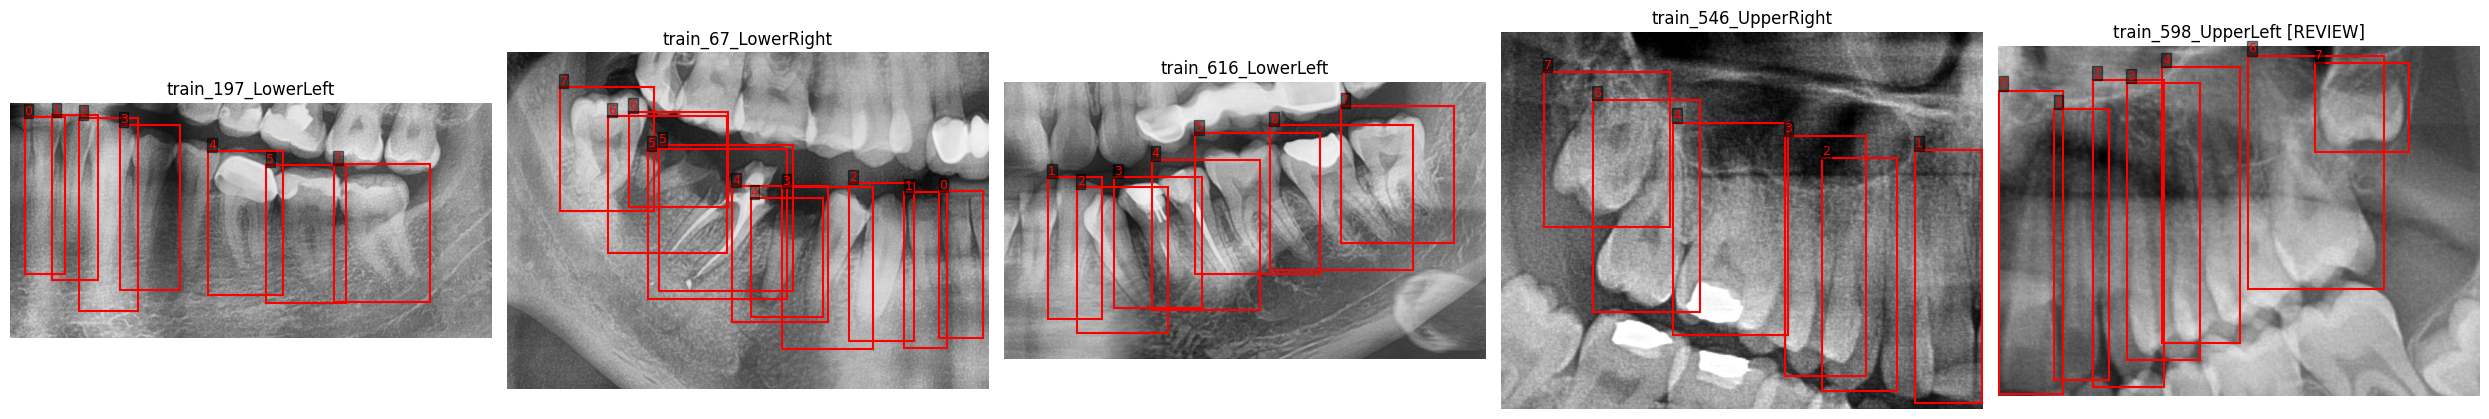

 80%|████████  | 4/5 [00:00<00:00,  4.96it/s]


In [ ]:
# fname = np.random.choice(s3_train_log_df[~s3_train_log_df['event'].isin(allowed_events)][s3_train_log_df['n_boxes'] >= 9]['File_Name'].unique())

bad_train_files_2 = ['train_197_LowerLeft.png', 'train_67_LowerRight.png', 'train_616_LowerLeft.png', 'train_546_UpperRight.png',
                     'train_598_UpperLeft.png',] # => These 4 images only need to delete after fast review
export_teeth_in_quad_using_enum_model(enum_model_detection,enum_cont_data_yaml['DISEASE_ONLY']['train'],
                                      enum_cont_data_yaml['DISEASE_ONLY']['train'].replace('images','labels'),
                                      debugging=True,debug_limit=len(bad_train_files_2),
                                      specific_image_name=bad_train_files_2,
                                      background_area_ratio_high=5,leak_area_ratio=0.3,verbose=True,
                                      export_images=False,
                                      export_labels=False)


  0%|          | 0/1 [00:00<?, ?it/s]

Skipped: tooth 5 already has a disease label in train_156_LowerRight.png
Flagged for review: train_156_LowerRight.png -> tooth 6 box is 1.9x the median width, may span two teeth


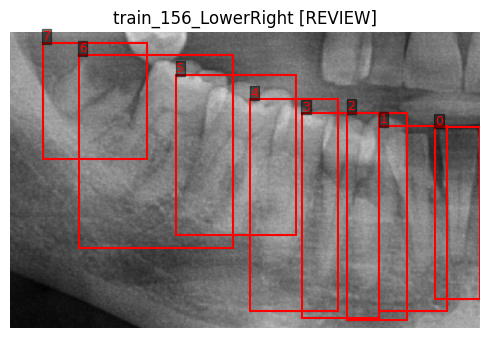

  0%|          | 0/1 [00:00<?, ?it/s]


In [ ]:
fname = np.random.choice(s3_valid_log_df[~s3_valid_log_df['event'].isin(allowed_events)][s3_valid_log_df['n_boxes'] >= 9]['File_Name'].unique())
# Nothing to delete
export_teeth_in_quad_using_enum_model(enum_model_detection,enum_cont_data_yaml['DISEASE_ONLY']['val'],
                                      enum_cont_data_yaml['DISEASE_ONLY']['val'].replace('images','labels'),
                                      debugging=True,debug_limit=1,
                                      specific_image_name=fname,
                                      background_area_ratio_high=5,leak_area_ratio=0.3,
                                      verbose=True,
                                      export_images=False,
                                      export_labels=False)

  0%|          | 0/1 [00:00<?, ?it/s]

Skipped: tooth 1 already has a disease label in train_590_UpperLeft.png
Skipped: tooth 0 already has a disease label in train_590_UpperLeft.png
Flagged for review: train_590_UpperLeft.png -> tooth 6 box is 2.0x the median width, may span two teeth


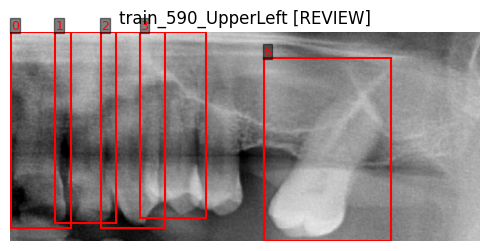

  0%|          | 0/1 [00:00<?, ?it/s]


In [ ]:
fname = np.random.choice(s3_test_log_df[~s3_test_log_df['event'].isin(allowed_events)][s3_test_log_df['n_boxes'] >= 9]['File_Name'].unique())

# Nothing to delete
export_teeth_in_quad_using_enum_model(enum_model_detection,enum_cont_data_yaml['DISEASE_ONLY']['test'],
                                      enum_cont_data_yaml['DISEASE_ONLY']['test'].replace('images','labels'),
                                      debugging=True,debug_limit=1,
                                      specific_image_name=fname,
                                      background_area_ratio_high=5,leak_area_ratio=0.3,
                                      verbose=True,
                                      export_images=False,
                                      export_labels=False)

## Export the final crops

With the bad images identified, we run the real export for train, valid, and test, skipping the flagged files this time, and print the file counts before and after.

In [ ]:
# combines every image flagged as bad during manual review above
bad_train_files = worst_train_files + bad_train_files_1 + bad_train_files_2
bad_valid_files = worst_valid_files
bad_test_files = worst_test_files

print('Before Train Export: ',len(os.listdir(enum_cont_data_yaml['DISEASE_ONLY']['train'])))

export_teeth_in_quad_using_enum_model(enum_model_detection,enum_cont_data_yaml['DISEASE_ONLY']['train'],
                                      enum_cont_data_yaml['DISEASE_ONLY']['train'].replace('images','labels'),
                                      output_root=os.path.join(stage2_cont_config['paths']['s2_cont_main_path'], 'train'),
                                      background_area_ratio_high=5,leak_area_ratio=0.3,
                                      skip_files=bad_train_files)

print('After Train Export: ',len(os.listdir(enum_cont_data_yaml['train'])))

# -------
print('='*40)
# -------

print('Before Valid Export: ',len(os.listdir(enum_cont_data_yaml['DISEASE_ONLY']['val'])))

export_teeth_in_quad_using_enum_model(enum_model_detection,enum_cont_data_yaml['DISEASE_ONLY']['val'],
                                      enum_cont_data_yaml['DISEASE_ONLY']['val'].replace('images','labels'),
                                      output_root=os.path.join(stage2_cont_config['paths']['s2_cont_main_path'], 'valid'),
                                      background_area_ratio_high=5,leak_area_ratio=0.3,
                                      skip_files=bad_valid_files)

print('After Valid Export: ',len(os.listdir(enum_cont_data_yaml['val'])))

# -------
print('='*40)
# -------

print('Before Test Export: ',len(os.listdir(enum_cont_data_yaml['DISEASE_ONLY']['test'])))

export_teeth_in_quad_using_enum_model(enum_model_detection,enum_cont_data_yaml['DISEASE_ONLY']['test'],
                                      enum_cont_data_yaml['DISEASE_ONLY']['test'].replace('images','labels'),
                                      output_root=os.path.join(stage2_cont_config['paths']['s2_cont_main_path'], 'test'),
                                      background_area_ratio_high=5,leak_area_ratio=0.3,
                                      skip_files=bad_test_files)

print('After Test Export: ',len(os.listdir(enum_cont_data_yaml['test'])))

Before Train Export:  1439


  8%|▊         | 108/1439 [00:05<01:15, 17.62it/s]

Bad Image train_140_UpperLeft.png Skipped Successfuly!


  8%|▊         | 117/1439 [00:06<01:12, 18.20it/s]

Bad Image train_143_UpperRight.png Skipped Successfuly!


...

After Valid Export:  179
Before Test Export:  175


 84%|████████▍ | 147/175 [00:09<00:01, 20.12it/s]

Bad Image train_621_LowerLeft.png Skipped Successfuly!


100%|██████████| 175/175 [00:10<00:00, 16.14it/s]

After Test Export:  174


## Augment the exported crops

Same augmentation pattern as before: define the config, run a debug pass to check a few samples, then apply it for real and confirm the file count change.

In [ ]:
ENUM_AUG_CONFIG = {
    'rotate_limit': 6,
    'rotate_p': 0.5,
    'brightness_limit': 0.1,
    'contrast_limit': 0.1,
    'brightness_contrast_p': 0.4,
    'center_crop_ratio': 1.0, # No need to center crop
    'clahe_clip_limit': 2.0,
    'clahe_p': 0.5,
    'resized_crop_scale': (0.9, 1.0),
    'ratio_margin_low': 0.95,
    'ratio_margin_high': 1.05,
    'resized_crop_p': 0.001,
    'min_visibility': 0.6,
}

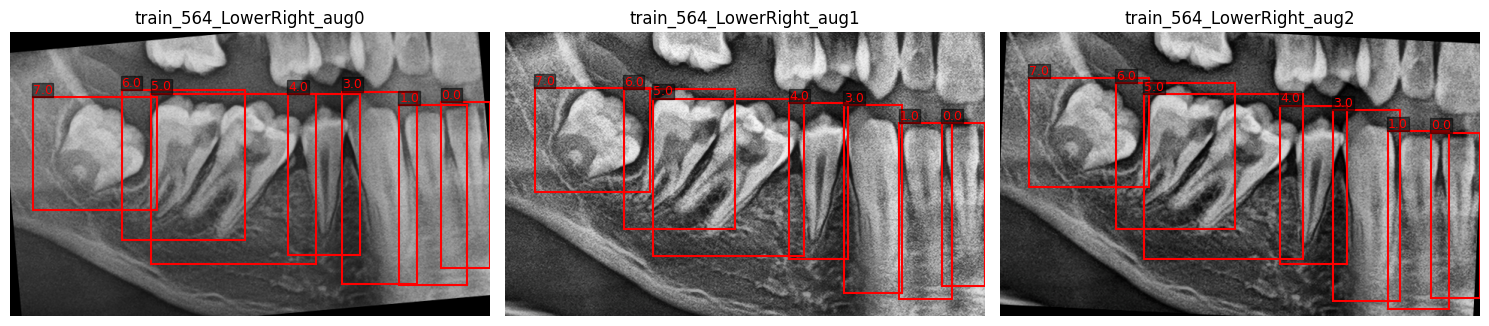

In [ ]:
apply_smart_aug(enum_cont_data_yaml,ENUM_AUG_CONFIG,apply_debug=True)

In [ ]:
apply_smart_aug(enum_cont_data_yaml,ENUM_AUG_CONFIG)

Augmenting Images Now...: 100%|██████████| 1419/1419 [02:42<00:00,  8.74it/s]


In [ ]:
print('Before Augmentation: ',len(os.listdir(enum_cont_data_yaml['DISEASE_ONLY']['train'])))

print('After Augmentation: ',len(os.listdir(enum_cont_data_yaml['train'])))

Before Train Export:  1439
After Train Export:  7353


In [3]:
build_and_export_dataframes(stage2_cont_config['paths']['s2_cont_main_path'],stage2_cont_config['paths']['s2_cont_main_path'])

train: 55548 rows -> ../Data/Processed/Stage 2 Continued (Healthy & Disease Enumeration Detection)\train_df.pkl
valid: 1289 rows -> ../Data/Processed/Stage 2 Continued (Healthy & Disease Enumeration Detection)\valid_df.pkl
test: 1273 rows -> ../Data/Processed/Stage 2 Continued (Healthy & Disease Enumeration Detection)\test_df.pkl


{'train':                     File_Name  \
 0      train_0_LowerRight.png   
 1      train_0_LowerRight.png   
 2      train_0_LowerRight.png   
 3      train_0_LowerRight.png   
 4      train_0_LowerRight.png   
 ...                       ...   
 55543  train_9_UpperRight.png   
 55544  train_9_UpperRight.png   
 55545  train_9_UpperRight.png   
 55546  train_9_UpperRight.png   
 55547  train_9_UpperRight.png   
 
                                                     Bbox  Height  Width  \
 0      [140.91552263498306, 177.72954627871513, 199.9...     495    782   
 1      [498.40520083904266, 289.14121717214584, 187.8...     495    782   
 2      [251.11471658945084, 212.45713904500008, 213.6...     495    782   
 3      [568.838130235672, 305.6227907538414, 124.2363...     495    782   
 4      [372.7926436662674, 261.1827367544174, 283.989...     495    782   
 ...                                                  ...     ...    ...   
 55543  [351.7261826992035, 291.26056575775146, 8